In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Set consistent style
plt.style.use('default')
fig_size_x = 8
fig_size_y = 4
plt.rcParams['font.size'] = 10

# Generate synthetic data for elephant seal population
# Using a logistic growth curve as the "true" relationship
def logistic_function(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Time points (years since protection)
time = np.linspace(0, 20, 100)
true_population = logistic_function(time, L=500, k=0.5, x0=8)

# Observed data points (with some noise)
np.random.seed(42)  # For reproducibility
observed_time = np.array([2, 4,  6, 8,  10, 12, 14, 16, 18])
observed_population = logistic_function(observed_time, L=500, k=0.5, x0=8) + np.random.normal(0, 50, len(observed_time))

# Synthetic SST data (Sea Surface Temperature)  
# SST varies with time, simulating seasonal and long-term patterns
observed_sst = 15 + 2 * np.sin(observed_time / 5) + 0.5 * observed_time + np.random.normal(0, 0.5, len(observed_time))

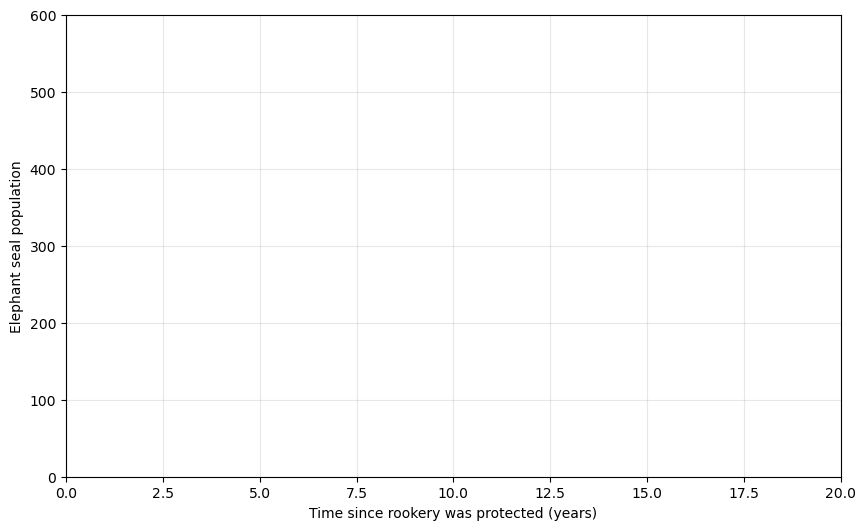

In [11]:

# GRAPH 1: Empty axes
plt.figure(figsize=(10, 6))
plt.xlabel('Time since rookery was protected (years)')
plt.ylabel('Elephant seal population')
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.ylim(0, 600)
plt.savefig(f'{image_dir}/graph1_empty_axes.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()



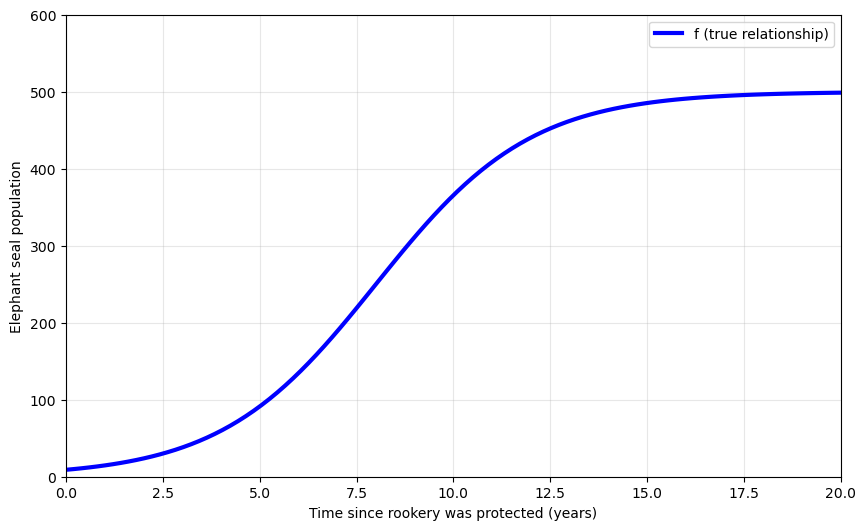

In [12]:

# GRAPH 2: True relationship (sigmoidal function f)
plt.figure(figsize=(10, 6)) 
plt.plot(time, true_population, 'b-', linewidth=3, label='f (true relationship)')
plt.xlabel('Time since rookery was protected (years)')
plt.ylabel('Elephant seal population')
#plt.title('"True Relationship" of elephant se')
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.ylim(0, 600)
plt.legend()
plt.savefig(f'{image_dir}/graph2_true_relationship.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


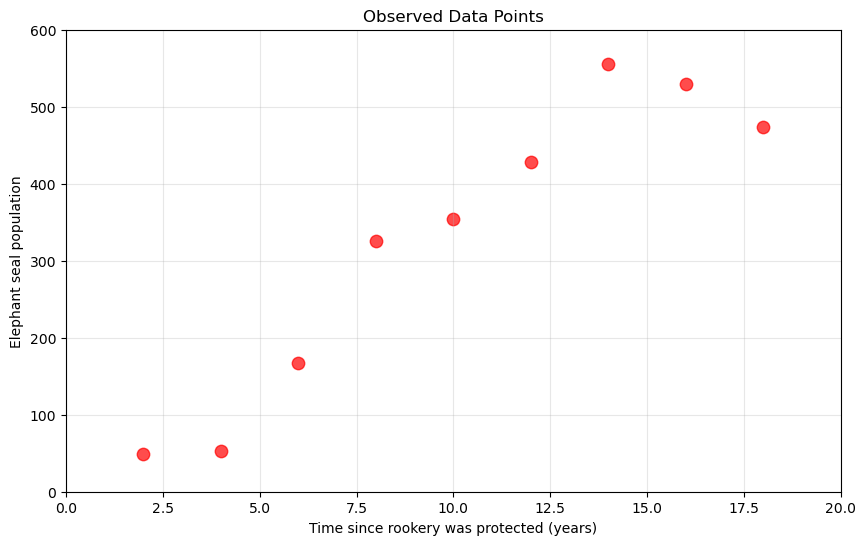

In [13]:

# GRAPH 3: Observed data points only
plt.figure(figsize=(10, 6))
plt.scatter(observed_time, observed_population, s=80, c='red', alpha=0.7)
plt.xlabel('Time since rookery was protected (years)')
plt.ylabel('Elephant seal population')
plt.title('Observed Data Points')
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.ylim(0, 600)
plt.savefig(f'{image_dir}/graph3_observed_data.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


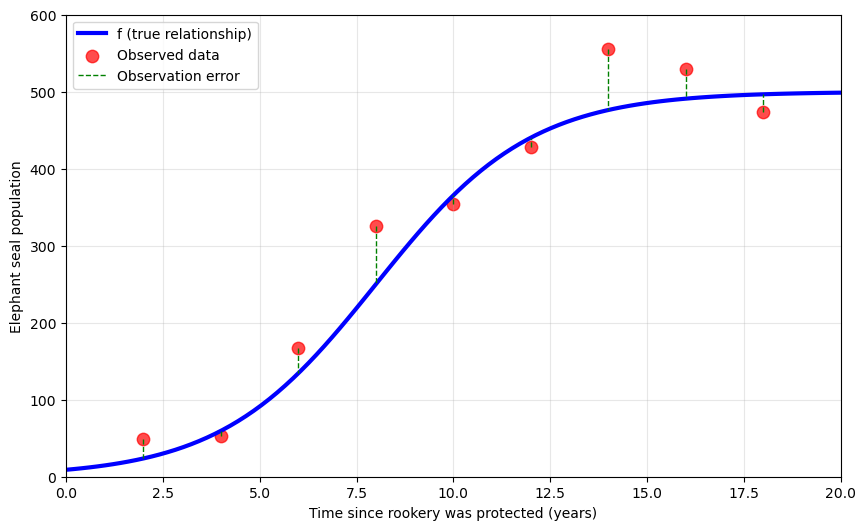

In [14]:

# GRAPH 4: Observed data with true function and error lines
plt.figure(figsize=(10, 6))
plt.plot(time, true_population, 'b-', linewidth=3, label='f (true relationship)')
plt.scatter(observed_time, observed_population, s=80, c='red', alpha=0.7, label='Observed data')

# Add error lines
i=0
for t, obs_pop in zip(observed_time, observed_population):
    true_pop = logistic_function(t, L=500, k=0.5, x0=8)
    if i==0:
        plt.plot([t, t], [obs_pop, true_pop], 'g--', linewidth=1, label="Observation error")
        i+=1
    else:
        plt.plot([t, t], [obs_pop, true_pop], 'g--', linewidth=1)

plt.xlabel('Time since rookery was protected (years)')
plt.ylabel('Elephant seal population')
#plt.title('GRAPH 4: Observed Data with True Function and Errors')
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.ylim(0, 600)
plt.legend(loc='upper left')
plt.savefig(f'{image_dir}/graph4_with_errors.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


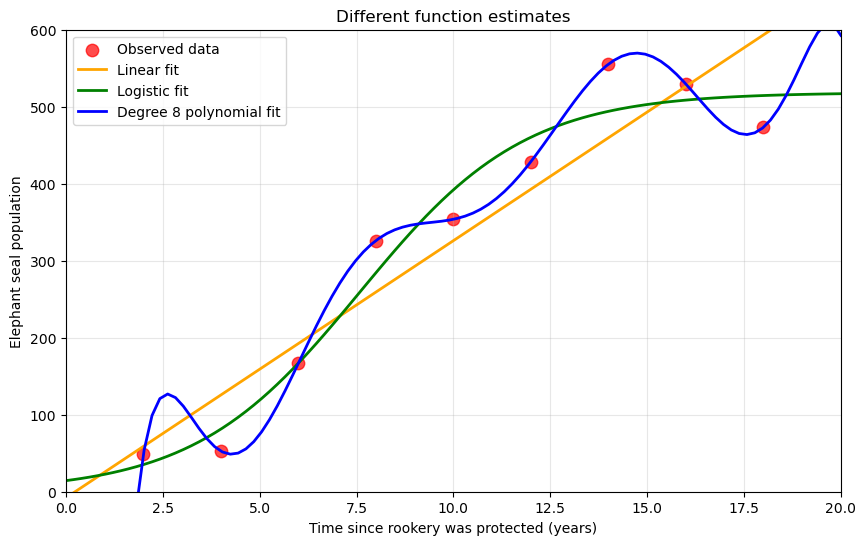

In [15]:

# GRAPH 5: Different function estimates
plt.figure(figsize=(10, 6))

plt.scatter(observed_time, observed_population, s=80, c='red', alpha=0.7, label='Observed data')

# Linear fit
linear_coeffs = np.polyfit(observed_time, observed_population, 1)
linear_fit = np.polyval(linear_coeffs, time)
plt.plot(time, linear_fit, 'orange', linewidth=2, label='Linear fit')

# Logistic fit (using curve_fit)
def logistic_simple(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

popt, _ = curve_fit(logistic_simple, observed_time, observed_population, p0=[500, 0.5, 8])
logistic_fit = logistic_simple(time, *popt)
plt.plot(time, logistic_fit, 'green', linewidth=2, label='Logistic fit')

# Overfitting (high degree polynomial)
poly_coeffs = np.polyfit(observed_time, observed_population, 8)
overfit = np.polyval(poly_coeffs, time)
plt.plot(time, overfit, 'blue', linewidth=2, label='Degree 8 polynomial fit')

plt.xlabel('Time since rookery was protected (years)')
plt.ylabel('Elephant seal population')
plt.title('Different function estimates')
plt.grid(True, alpha=0.3)
plt.xlim(0, 20)
plt.ylim(0, 600)
plt.legend()
plt.savefig(f'{image_dir}/graph5_function_estimates.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [16]:
observed_time

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18])

In [17]:
observed_population

array([ 48.54864424,  52.68824595, 166.85513759, 326.15149282,
       353.82162058, 428.69169114, 555.24770419, 529.37863148,
       473.17985524])

Linear Model: Population = -1112.46 + 10.10*Time + 64.58*SST


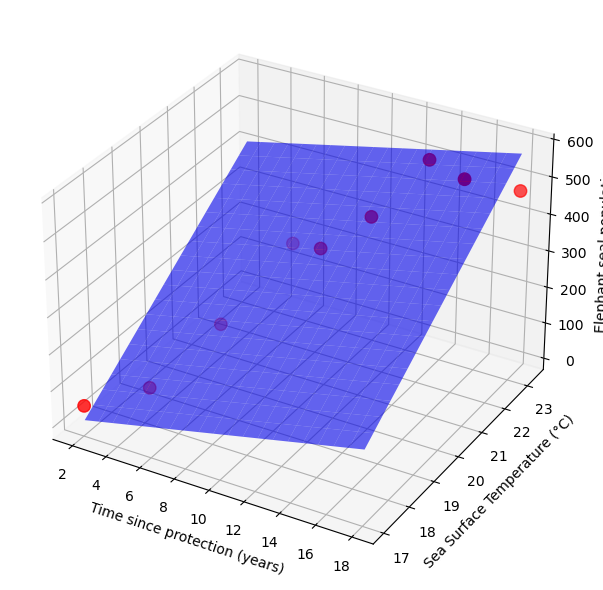

In [22]:
# Linear model fitting with two predictors: time and SST

# Prepare data for linear regression
X = np.column_stack([observed_time, observed_sst])  # Predictors
y = observed_population  # Response

# Fit linear model
model = LinearRegression()
model.fit(X, y)

# Get model parameters
beta_0 = model.intercept_
beta_1, beta_2 = model.coef_

print(f"Linear Model: Population = {beta_0:.2f} + {beta_1:.2f}*Time + {beta_2:.2f}*SST")

# Create prediction surface for visualization
time_range = np.linspace(observed_time.min(), observed_time.max(), 20)
sst_range = np.linspace(observed_sst.min(), observed_sst.max(), 20)
time_mesh, sst_mesh = np.meshgrid(time_range, sst_range)
population_mesh = beta_0 + beta_1 * time_mesh + beta_2 * sst_mesh

# 3D visualization
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the fitted plane
ax.plot_surface(time_mesh, sst_mesh, population_mesh, alpha=0.6, color='blue', label='Fitted plane')

# Plot the observed data points
ax.scatter(observed_time, observed_sst, observed_population, color='red', s=80, label='Observed data')

ax.set_xlabel('Time since protection (years)')
ax.set_ylabel('Sea Surface Temperature (°C)')
ax.set_zlabel('Elephant seal population')
#ax.set_title('Linear Model: Population ~ Time + SST')
#ax.legend()

plt.tight_layout()
plt.show()
plt.close()

In [24]:
observed_sst


array([17.05011671, 18.20300334, 19.6312133 , 21.12012834, 20.86195473,
       21.48846744, 22.38883254, 22.37683615, 23.27208278])

In [25]:

deep_long    = np.random.multivariate_normal([550, 45], [[1500, 30], [30, 20]], 30)
shallow_freq = np.random.multivariate_normal([150, 12], [[800, 20], [20, 8]],  30)
medium       = np.random.multivariate_normal([350, 28], [[1000, 25], [25, 12]], 30)

In [26]:
deep_long

array([[585.29351706,  39.49454638],
       [493.25595895,  42.85581108],
       [547.51175009,  38.67420176],
       [571.07390112,  45.91556292],
       [594.54415596,  47.5573339 ],
       [573.28859621,  44.18709123],
       [573.13869659,  53.62729583],
       [550.61710041,  40.35375791],
       [518.25196636,  38.97945023],
       [542.08558793,  36.20816415],
       [601.42272638,  46.90901073],
       [521.38410075,  45.17498711],
       [554.50588777,  43.76507034],
       [607.32697459,  42.99096294],
       [567.74611155,  50.01572356],
       [536.84903388,  36.96812884],
       [537.48266765,  43.05025845],
       [576.16244023,  48.22426374],
       [509.98658826,  48.29112463],
       [582.53025298,  44.29718345],
       [537.08322984,  49.03512304],
       [568.57485151,  44.55861755],
       [592.95476712,  40.60158965],
       [518.41010591,  50.33356072],
       [552.69940922,  49.47481093],
       [536.05148413,  41.87591058],
       [535.86603998,  51.48798476],
 

In [28]:
shallow_freq

array([[147.54190056,   6.49476844],
       [156.18857531,  13.1341736 ],
       [108.23476504,   9.52664837],
       [172.90224007,  11.20384871],
       [124.08588887,  12.2463447 ],
       [164.94838572,  13.78288902],
       [147.18733705,  14.58176986],
       [169.87963225,  11.60434878],
       [161.1915439 ,   8.27442205],
       [141.60644789,  12.50310804],
       [149.87157275,  11.35431371],
       [190.0616642 ,  11.85902579],
       [159.74881398,  10.04889204],
       [154.5339278 ,  13.22096235],
       [ 96.63870749,  11.13145327],
       [142.72053852,  11.61241314],
       [204.27271499,  13.29703879],
       [148.12630366,  18.69860103],
       [155.41994589,  12.96260402],
       [151.06251368,   8.8262479 ],
       [117.62425059,  13.24221082],
       [127.68911509,   8.9464851 ],
       [110.41992804,   7.1620011 ],
       [133.24993155,  17.57611553],
       [178.05562822,  11.15714942],
       [147.21621675,  10.55091824],
       [193.85451875,  13.29450004],
 

In [29]:
healthy    = np.random.multivariate_normal([200, 180], [[300, 50], [50, 40]], 30)
malnourish = np.random.multivariate_normal([130, 155], [[200, 40], [40, 30]], 30)
injured    = np.random.multivariate_normal([170, 165], [[250, 40], [40, 30]], 30)


In [32]:
injured 

array([[164.98974807, 163.48421071],
       [167.97376134, 167.53829403],
       [181.18003728, 177.148501  ],
       [186.89381744, 162.06959191],
       [151.05591952, 165.5137368 ],
       [159.62313949, 166.22857578],
       [170.93920489, 160.80058171],
       [169.36596643, 161.59410352],
       [154.72556451, 161.59363509],
       [183.30135598, 165.77991704],
       [163.94859996, 161.19153803],
       [182.77990523, 168.43696724],
       [166.55348638, 161.92667879],
       [177.24458089, 167.40516962],
       [194.03450206, 162.38737417],
       [181.52131754, 165.99140928],
       [163.86454195, 171.09626658],
       [156.59091097, 161.85959941],
       [171.13359988, 160.32269689],
       [170.53225835, 163.68952991],
       [165.59205572, 160.19919152],
       [160.52569153, 170.78719488],
       [171.38335181, 167.19792318],
       [159.43646623, 161.18714826],
       [166.45121927, 164.43605202],
       [169.10029804, 161.08102628],
       [169.19903968, 167.28150831],
 